# Customer Churn Prediction

### Basic Information and Dataset Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style("whitegrid")

### Dataset Loading and Basic Inspection

In [3]:
# Load dataset
df = pd.read_csv("../data/Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Inspect columns, dtypes and counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


#### EDA

In [6]:
# Check for null values, if any
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Duplicates

In [7]:
# Check duplicated values, if any
df[df.duplicated()] # or df.duplicated().sum()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


#### Basic Statistical Analysis

In [8]:
# Describe for statistical basic analysis - for numerical values (default)
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Two facts surface from the statistical analysis output**, worth flaggin in advance:

- The target/label column _Exited_ has a mean of 20% approx, which means there is a clear imbalance already on the number of people churning against the people that didn't. This should be taken into account as a factor disrupting or making accuracy measurements trivial; as it would mean that by simply guessing 'non-churned/non-exited' (i.e: using a DummyRegressor), 80% of the time the prediction would be correct. For this later on appropriate measurements for classification such as precision/recall/F1 will be used.

- The _balance_ column at the 25th percentile is 0.0, which then jumps to 97.198. This is a hint that is not a smooth distribution, rather a spike at zero followed by a roughly normal-looking distribution above it. Worth checking later with bi-variate analysis potential correlations with exited, if any.

In [9]:
# and for categorical values
df.describe(include="object")

/tmp/ipykernel_97733/2108447761.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


Nothing too relevant stands out (France is the most frequent country of origin, which hints at a bank dataset -also guessed by the columns names- but irrelevant for potential clues)

### Univariate Analysis

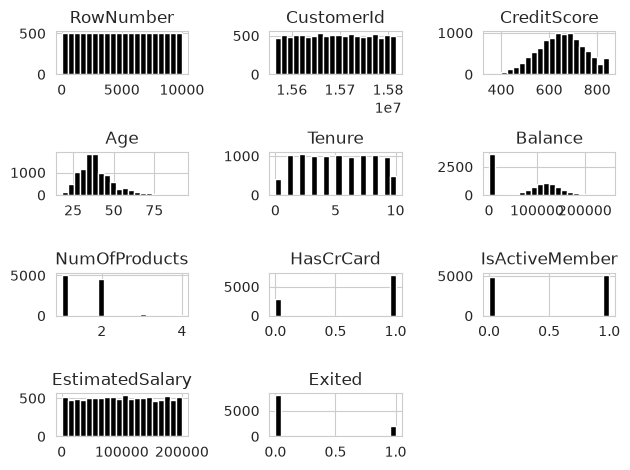

In [10]:
# Histogram for numerical values distribution
df.hist(bins=20, color="black")
plt.tight_layout()
plt.show()

**Observations**

- Identifiers columns (RowNumber, CustomerId) are to be blacklisted later from the actual features list for the model is picked. These only serve as book keeping for the dataset owner. (they could've been dropped in a diff filtered DF as well)
- **CreditScore** displays an almost normal distribution, with the caveat that there is a spike. However, the spike seems to be a cap at the value 850, rather than outliers. To confirm this we can execute below code:

In [11]:
df[df.CreditScore == 850].shape

(233, 14)

Code above confirms the CreditScore column is a ceiling rather than outliers.

- **Tenure** would look like an small flat distribution, however, without bi-variate analysis (see later) we cannot rule this has a correlation/impact with the target variable for churn (exited).
- **Balance** confirms the shape and the spike from the statistical analysis at the graphical level. Above zero we can see a fairly clean, roughly bell-shape distribution
- **NumOfProducts, HasCrCard, IsActiveMember** as oddly distributed as they might seen don't inform in this type of analysis of potential impact/correlation with the target variable. Best to hold conclusions
- **Salary** being almost flat hints at potentially a synthetically generated column for the dataset composition.

In [25]:
# Categorical columns
categorical_columns = df.drop(columns="Surname").describe(include=["object", "str"])

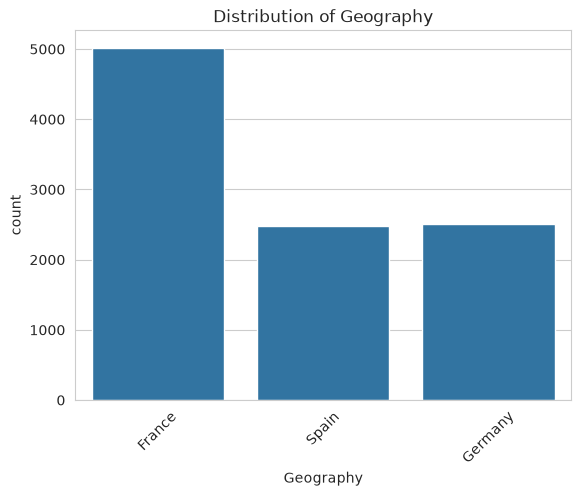

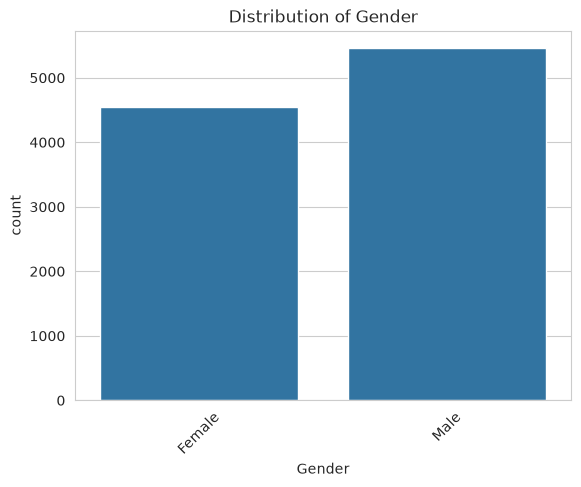

In [26]:
# Visualize with Count Plots and draw observations
for col in categorical_columns:
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [27]:
# Visualize percentages of the plots
df.Geography.value_counts(normalize=True)

Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

Visualization of the percentages corresponding to the count plots yields more information, i.e.: for the _Geography_ feature, France has 50% of the customer base, the rest is split between Germany and Spain.

In [17]:
# Scatter plot for numerical columns
numerical_columns = df.drop(['RowNumber', 'CustomerId'], axis=1).describe(include="number").columns

**Cardinality**